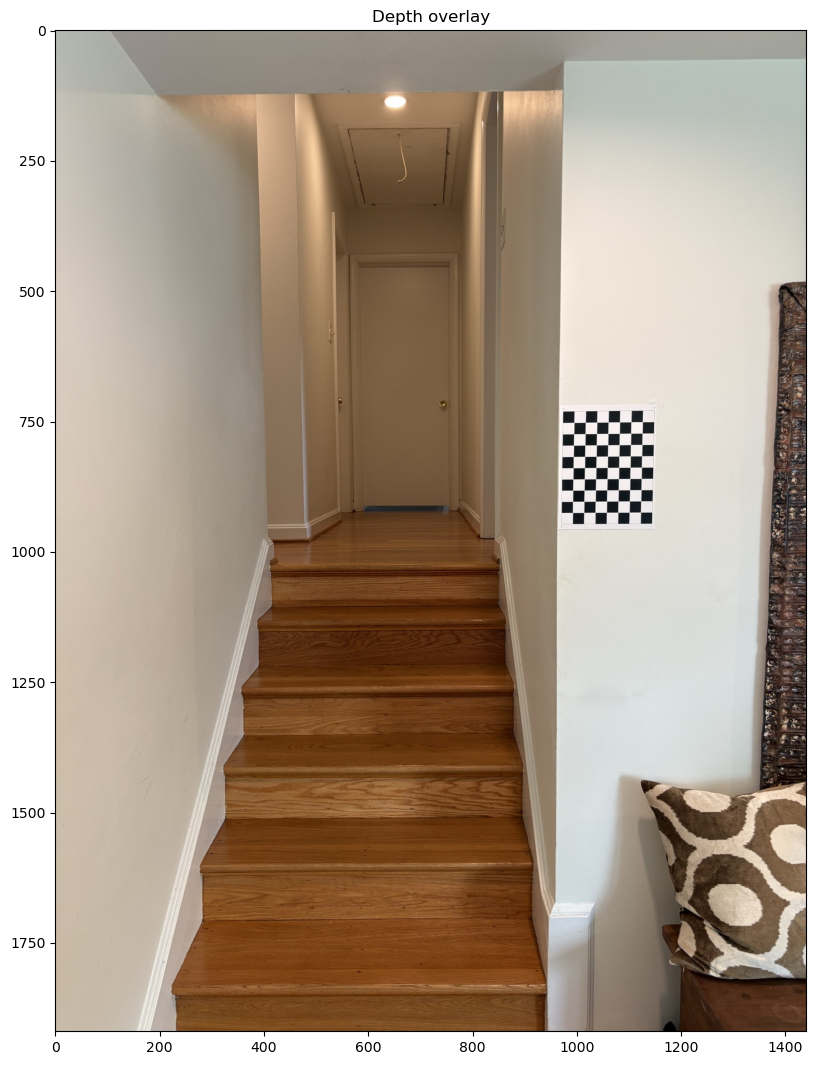

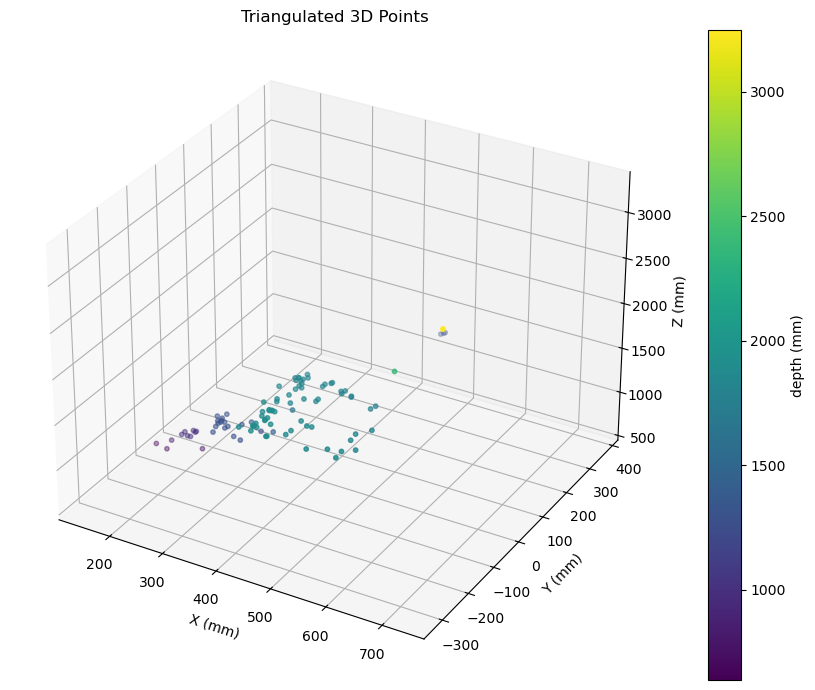

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import cv2


df = pd.read_csv("output/points3d.csv")
df = df[df['z'] > 0]

# load image for reference
img = cv2.imread("data/right.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# you need the original 2D inlier pixel locations too
# add this to your C++ — save inlier pixel coords alongside points3d.csv
# for now just show the scatter on top of the image
fig, ax = plt.subplots(figsize=(10, 13))
ax.imshow(img)
ax.set_title("Depth overlay")
plt.show()

df = pd.read_csv("output/points3d.csv")

# filter outliers
df = df[df['z'] < df['z'].quantile(0.95)]
df = df[df['z'] > 0]  # points must be in front of camera

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(df['x'], df['y'], df['z'], 
                s=10, c=df['z'], cmap='viridis')

plt.colorbar(sc, label='depth (mm)')
ax.set_xlabel('X (mm)')
ax.set_ylabel('Y (mm)')
ax.set_zlabel('Z (mm)')
ax.set_title('Triangulated 3D Points')

plt.tight_layout()
plt.show()

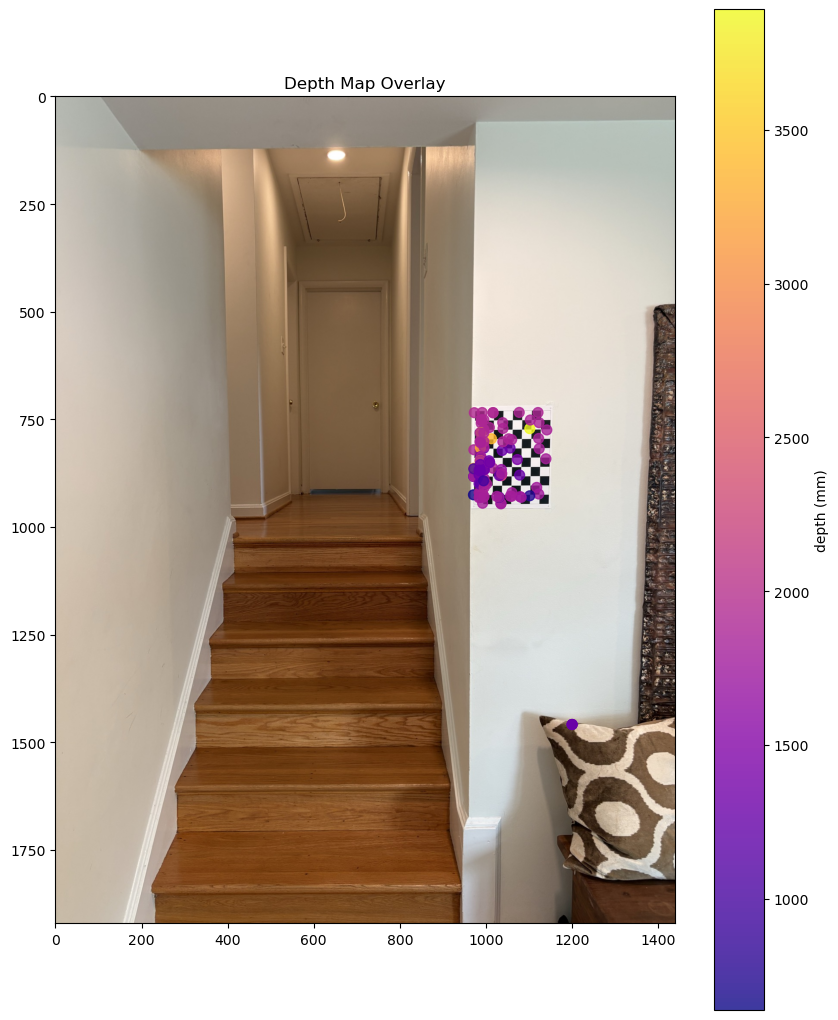

In [4]:
df = pd.read_csv("output/points3d.csv")
df = df[df['z'] > 0]

img = cv2.imread("data/right.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(figsize=(10, 13))
ax.imshow(img)
sc = ax.scatter(df['u'], df['v'], 
                c=df['z'], cmap='plasma', 
                s=50, alpha=0.8)
plt.colorbar(sc, label='depth (mm)')
ax.set_title('Depth Map Overlay')
plt.show()

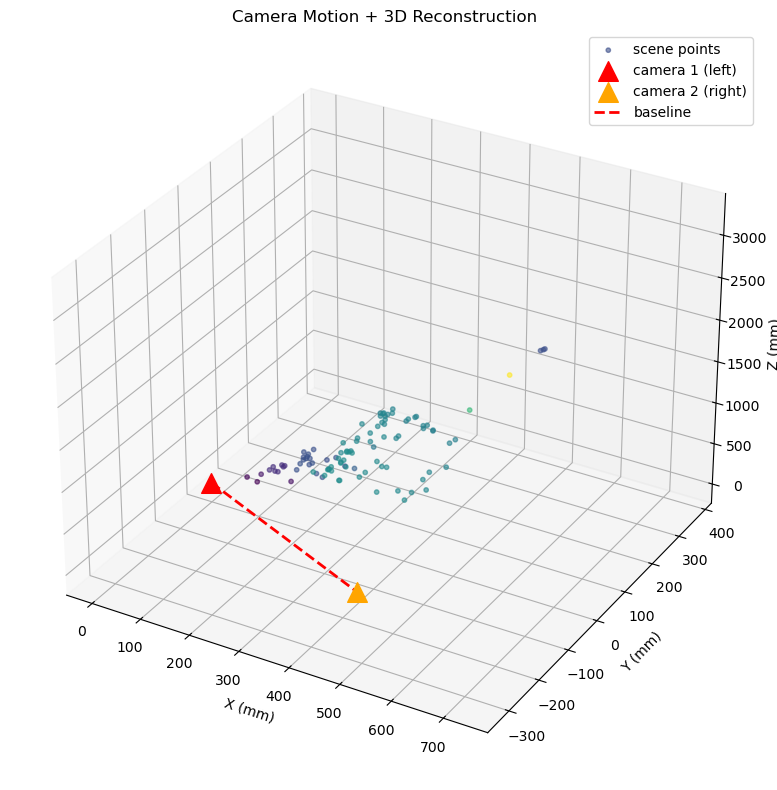

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import yaml

# load points
df = pd.read_csv("output/points3d.csv")
df = df[df['z'] > 0]
df = df[df['z'] < df['z'].quantile(0.95)]

# load R and t from essential.yml
import cv2
fs = cv2.FileStorage("output/essential.yml", cv2.FILE_STORAGE_READ)
R = fs.getNode("rotation_matrix").mat()
t = fs.getNode("translation_vector").mat().flatten()
fs.release()

# camera 1 is at origin
cam1 = np.array([0, 0, 0])

# camera 2 position: -R.T @ t
cam2 = -R.T @ t

# scale t to match scene scale (t is unit length, scale by median depth)
scene_scale = df['z'].median()
cam2_scaled = cam2 * scene_scale / 100  # rough visual scale

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# plot 3D points
ax.scatter(df['x'], df['y'], df['z'],
           s=10, c=df['z'], cmap='viridis', alpha=0.6, label='scene points')

# plot camera positions
ax.scatter(*cam1, color='red', s=200, marker='^', label='camera 1 (left)', zorder=5)
ax.scatter(cam2_scaled[0] + df['x'].mean(),
           cam2_scaled[1] + df['y'].mean(), 
           cam2_scaled[2],
           color='orange', s=200, marker='^', label='camera 2 (right)', zorder=5)

# draw baseline between cameras
ax.plot([cam1[0], cam2_scaled[0] + df['x'].mean()],
        [cam1[1], cam2_scaled[1] + df['y'].mean()],
        [cam1[2], cam2_scaled[2]],
        'r--', linewidth=2, label='baseline')

ax.set_xlabel('X (mm)')
ax.set_ylabel('Y (mm)')
ax.set_zlabel('Z (mm)')
ax.set_title('Camera Motion + 3D Reconstruction')
ax.legend()

plt.tight_layout()
plt.savefig("output/camera_motion.png")
plt.show()